# Bright High-z Targets


No targets fall within a 3.6' NIRSpec MSA radius.


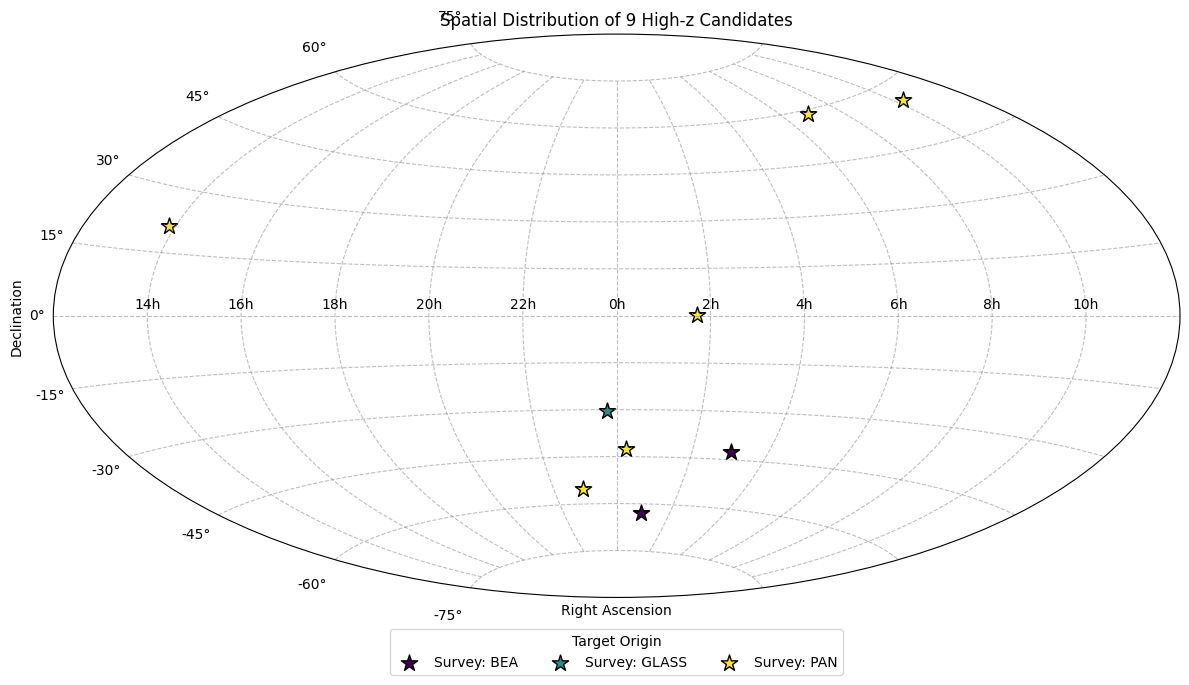

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import collections

# --- 1. Coordinate and Survey Data (Replace with your ~20 targets) ---

# Example target data (IDs, full strings, and originating survey)
targets_data = [
    ("PAN-0104-5508-2026296", "01:04:17.50 -55:07:35.55", "PAN"),
    ("PAN-1007+2109-2040861", "10:07:44.02 +21:11:00.98", "PAN"),
    ("PAN-1343+5549-2000350", "13:43:39.91 +55:46:45.76", "PAN"),
    ("PAN-1707+5852-2010068", "17:07:17.36 +58:51:11.06", "PAN"),
    ("BEA-2303-6250-2039802", "23:03:34.42 -62:50:11.26", "BEA"),
    ("GLASS-2039052", "00:13:59.75 -30:19:29.14", "GLASS"),
    ("BEA-2303-6250-2039802", "20:58:33.74 -42:44:08.61", "BEA"),
    ("PAN-2216+0024-3003658", "22:17:00.12 +00:22:44.69", "PAN"), 
    ("PAN-2345-4235-3022235", "23:45:15.45 -42:34:57.07", "PAN"), 
]

# Extract coordinates and surveys
coord_strings = [t[1] for t in targets_data]
survey_list = [t[2] for t in targets_data]

# Parse with Astropy
coords = SkyCoord(coord_strings, unit=(u.hourangle, u.deg), frame='icrs')

# Check for multipletarget pointings (MSA radius ~3.6 arcmin)
max_sep = 3.6 * u.arcmin
from astropy.coordinates import search_around_sky
idx1, idx2, sep2d, _ = search_around_sky(coords, coords, seplimit=max_sep)
unique_pairs = idx1 < idx2
matching_pairs = list(zip(idx1[unique_pairs], idx2[unique_pairs], sep2d[unique_pairs]))

# Identify pointings with multiples (using indices of targets with neighbors)
multiple_target_indices = set(idx1[unique_pairs]) | set(idx2[unique_pairs])

# --- 2. Map Categorization & Color Setup ---

# Get unique surveys and map colors
unique_surveys = sorted(list(set(survey_list)))
color_map_name = 'viridis' # 'Set1', 'Dark2', 'plasma' also good for categorization
cmap = plt.get_cmap(color_map_name, len(unique_surveys))
survey_colors = {survey: cmap(i) for i, survey in enumerate(unique_surveys)}

# Handle coordinate wrapping and radian conversion for Aitoff
# Center the map at RA=0 (wrapping at 180 deg)
ra_wrapped = coords.ra.wrap_at(180 * u.deg)
ra_rad = ra_wrapped.radian
dec_rad = coords.dec.radian

# --- 3. Plot Initialization (Aitoff) ---
fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(111, projection='aitoff')
ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# Flip the X-axis manually (Astronomy convention, RA increasing Left)
# ax.set_xlim(np.pi, -np.pi)

# Set grid labels (formatting in standard RA/Dec hours/degrees)
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'])
# ax.set_yticklabels(['-75°', '-60°', '-45°', '-30°', '-15°', '0°', '15°', '30°', '45°', '60°', '75°']) # Can adjust y-ticks

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
plt.title(f"Spatial Distribution of {len(targets_data)} High-z Candidates")

# --- 4. Plot Targets with Color Coding ---
marker_size = 150

# Track plotted surveys for the legend
plotted_surveys = set()

for i, (ra, dec, survey) in enumerate(zip(ra_rad, dec_rad, survey_list)):
    
    # Define visual properties
    color = survey_colors[survey]
    edge_color = 'black'
    alpha = 1.0
    
    # Highlight potential multiplets with a slightly different style
    if i in multiple_target_indices:
        marker = 'D' # Diamond for multiples
        linewidth = 2.0
    else:
        marker = '*' # Star for singles
        linewidth = 1.0

    # Plot, adding to legend only once per survey
    if survey not in plotted_surveys:
        ax.scatter(-ra, dec, color=color, marker=marker, s=marker_size, 
                   edgecolors=edge_color, linewidths=linewidth, alpha=alpha, label=f"Survey: {survey}")
        plotted_surveys.add(survey)
    else:
        ax.scatter(-ra, dec, color=color, marker=marker, s=marker_size, 
                   edgecolors=edge_color, linewidths=linewidth, alpha=alpha)

# --- 5. Format Legend and Display Info ---
# Collect legend handles and labels, ensuring they are in order of plotted surveys
handles, labels = ax.get_legend_handles_labels()
# Sorting the legend by survey name
by_label = collections.OrderedDict(sorted(zip(labels, handles), key=lambda t: t[0]))
plt.legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=len(unique_surveys), title="Target Origin", frameon=True)

# Annotate multiplexing information
if matching_pairs:
    print(f"\nPotential Multi-Target NIRSpec Pointings Found:")
    for m in matching_pairs:
        t1 = targets_data[m[0]][0]
        t2 = targets_data[m[1]][0]
        print(f"  Targets {t1} and {t2} separated by {m[2].to(u.arcmin):.2f}")
else:
    print("\nNo targets fall within a 3.6' NIRSpec MSA radius.")

plt.tight_layout()
plt.show()

In [2]:
import astropy.units as u
from astropy.coordinates import search_around_sky

# Define your search radius (e.g., 3 arcminutes for NIRSpec MSA footprint)
max_sep = 3.0 * u.arcmin

# Compare the target list against itself
idx1, idx2, sep2d, dist3d = search_around_sky(coords, coords, seplimit=max_sep)

# Filter out self-matches (where a target matches with itself at 0 distance)
unique_pairs = idx1 < idx2
idx1 = idx1[unique_pairs]
idx2 = idx2[unique_pairs]
sep2d = sep2d[unique_pairs]

# Print the results
if len(idx1) > 0:
    print(f"Found {len(idx1)} potential multi-target pointings:")
    for i, j, sep in zip(idx1, idx2, sep2d):
        print(f"  Target {i} and Target {j} are separated by {sep.to(u.arcmin):.2f}")
else:
    print("No multiple targets found within the specified pointing radius.")

No multiple targets found within the specified pointing radius.


# LRD Selection

- MCMC fit to Ly-alpha + continuum restframe UV
- AB magnitude > 27

In [ ]:
# w/ ABmag > 27:

